In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px
import inspect
import time
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
%matplotlib inline

In [2]:
# Read the CSV file into a DataFrame
df = pd.read_csv(r"D:\HN -Air\Air_Quality-Analysis_HN\data\hanoi-aqi-weather-data.csv")  # Replace 'file.csv' with the path to your CSV file

# Convert 'Local Time' column to datetime object
df['Local Time'] = pd.to_datetime(df['Local Time'])

# Set 'Local Time' column as index
df.set_index('Local Time', inplace=True)

# Display the DataFrame
df  # Use df.head() to display the first few rows of the DataFrame

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
Local Time,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.00,62.3,87,0.0,1024,73,14.8,0.0,0.66
2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.00,59.0,87,0.0,1023,75,14.6,0.0,1.00
2023-01-01 02:00:00,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.00,58.0,83,0.0,1023,79,14.3,0.0,1.00
2023-01-01 03:00:00,2022-12-31T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.00,57.0,79,0.0,1023,82,14.1,0.0,1.00
2023-01-01 04:00:00,2022-12-31T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.00,56.0,75,0.0,1022,86,13.8,0.0,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 15:00:00,2024-12-31T08:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,173,605.0,15.0,27.0,100.0,73.00,26.0,37,0.0,1018,82,16.8,0.0,2.00
2024-12-31 16:00:00,2024-12-31T09:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,165,806.0,8.0,15.1,94.0,67.00,26.0,1,0.0,1018,86,16.0,0.0,2.00
2024-12-31 17:00:00,2024-12-31T10:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,183,1310.0,10.3,10.8,108.0,80.33,28.0,0,0.0,1018,90,15.2,0.0,2.00


In [33]:
df_pm25_hourly = df[['PM25']].copy()
df_pm25_daily = df_pm25_hourly.resample('D')['PM25'].agg('mean')
df_pm25 = df_pm25_daily
df_pm25

Local Time
2023-01-01     71.541667
2023-01-02     90.375000
2023-01-03     65.916667
2023-01-04     97.166667
2023-01-05     72.500000
                 ...    
2024-12-27     49.958333
2024-12-28     44.167083
2024-12-29     78.597083
2024-12-30    100.277917
2024-12-31     86.299500
Freq: D, Name: PM25, Length: 731, dtype: float64

In [4]:
df_pm25.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 731 entries, 2023-01-01 to 2024-12-31
Freq: D
Series name: PM25
Non-Null Count  Dtype  
--------------  -----  
731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [5]:
# Perform ADF test
adf_result = adfuller(df_pm25)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -6.5148641359401935
p-value: 1.0776256378814557e-08
Critical Values: {'1%': -3.4393644334758475, '5%': -2.8655182850048306, '10%': -2.568888486973192}


+ ADF Statistic (-6.5149) nhỏ hơn tất cả các giá trị Critical Values tại các mức ý nghĩa 1%, 5%, và 10%. Điều này cho thấy chuỗi thời gian của bạn là stationary và không có đơn vị gốc.
+ Gía trị p-value < 0.05, kết luận chúng ta sẽ bác bỏ giả thuyết  null (null hypothesis)
. Phương trình đặc trưng không có nghiệm đơn vị. Do đó chuỗi lợi suất có tính chất dừng.

<Axes: title={'center': 'Hanoi PM2.5 Levels, Daily Data'}, xlabel='Date', ylabel='PM2.5 Level'>

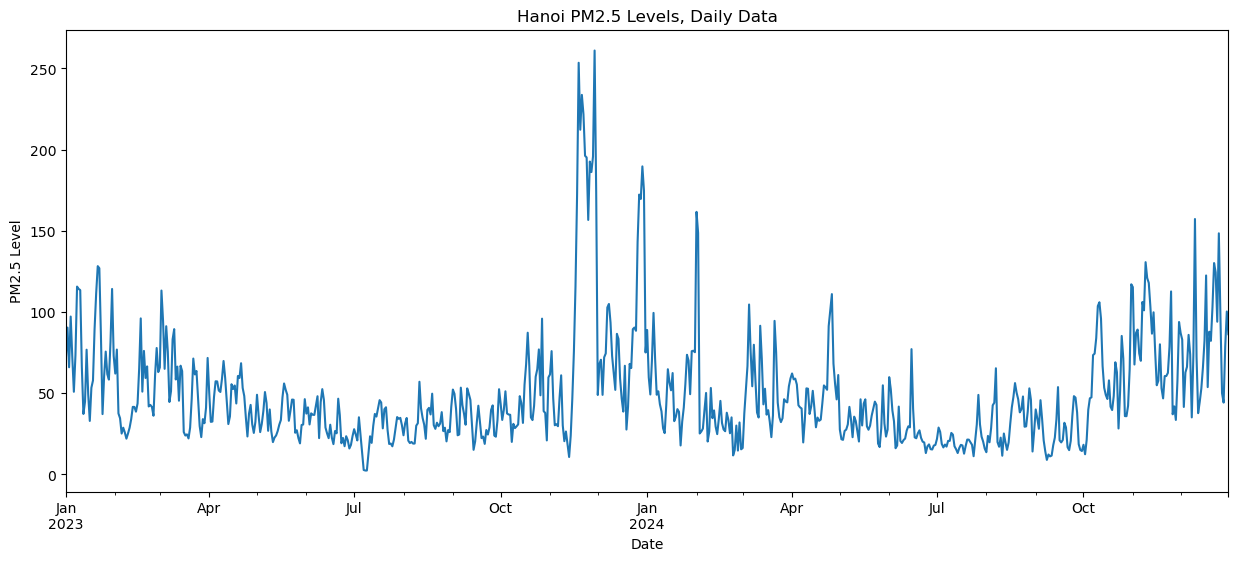

In [34]:
fig, ax = plt.subplots(figsize=(15, 6))
df_pm25.plot(xlabel = "Date",ylabel= "PM2.5 Level",
                           title= "Hanoi PM2.5 Levels, Daily Data", ax=ax)

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, ACF')

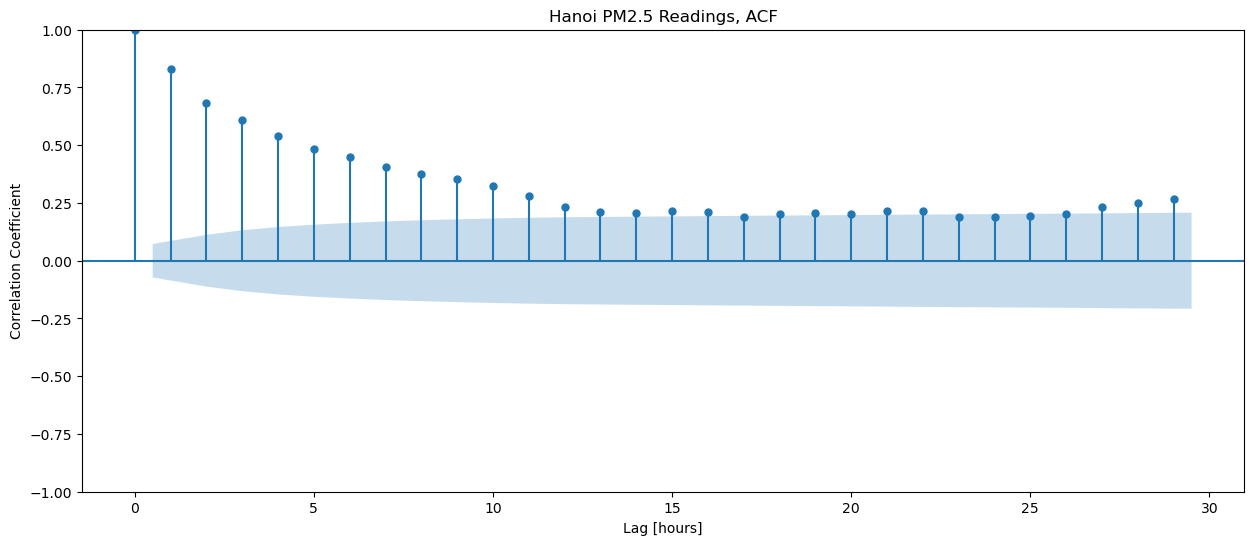

In [7]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, ACF")

 Nếu tại một độ trễ nhỏ nhất mà đoạn thẳng (vuông góc với trục hoành) mà độ dài đại diện cho giá trị của hệ số tự tương quan nằm ngoài khoảng tin cậy thì đó chính là độ trễ phù hợp lớn nhất mà ta nên lựa chọn cho quá trình trung bình trượt. Thông thường tôi chỉ chọn tối đa là 5. q= 5
 
q là tham số cho phần Moving Average (MA) trong mô hình ARIMA. Để chọnq, bạn cần tìm độ trễ (lag) tại đó hệ số tự tương quan vượt qua vùng tin cậy 95% và sau đó không còn vượt qua các độ trễ lớn hơn.ất.

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, PACF')

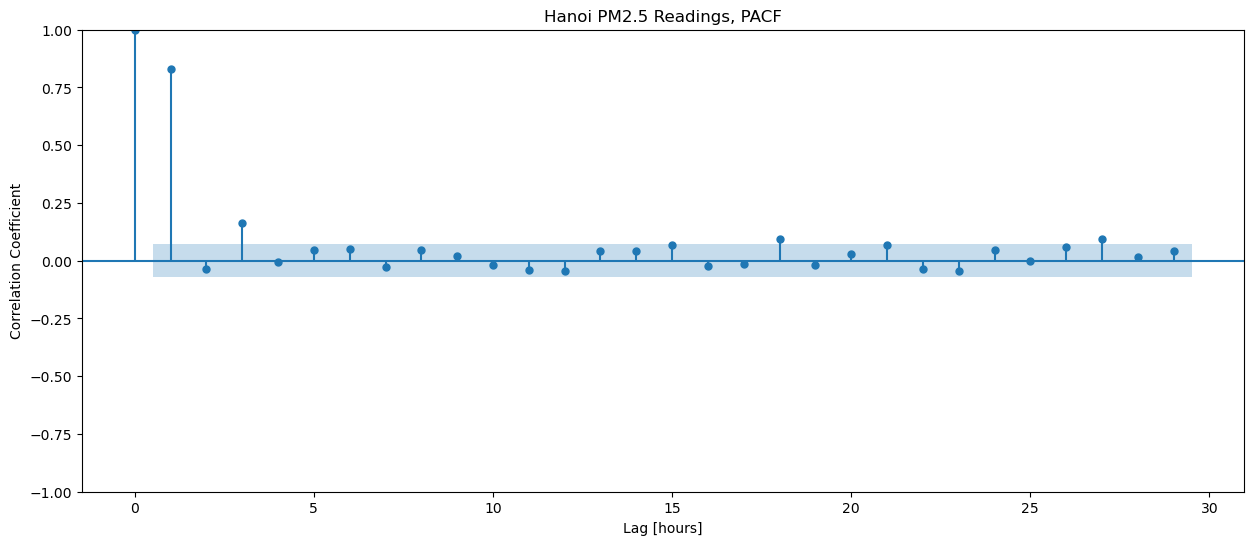

In [8]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, PACF")

p là độ trễ đầu tiên mà hệ số tự tương quan vượt ra ngoài vùng tin cậy và không còn điểm nào ở sau đó vượt ra ngoài vùng tin cậy. p = 1
 ( p d q ) = ( 1 0 5 )

In [9]:
int(len(df_pm25)) *0.8

584.8000000000001

In [10]:
cutoff_test = int(len(df_pm25)* 0.8) 
df_pm25_train = df_pm25.iloc[:cutoff_test]
df_pm25_test = df_pm25.iloc[cutoff_test:]
print("df_pm25_train shape:", df_pm25_train.shape)
print("df_pm25_test shape:", df_pm25_test.shape)

df_pm25_train shape: (584,)
df_pm25_test shape: (147,)


The data will be splitted into 80% of training data and 20% of test data

In [11]:
# Perform ADF test
adf_result = adfuller(df_pm25_train)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -5.83051260552405
p-value: 3.9853228609948983e-07
Critical Values: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}


In [12]:
df_pm25_train_mean = df_pm25_train.mean()
df_pm25_pred_baseline = [df_pm25_train_mean]*len(df_pm25_train)
mae_baseline = mean_absolute_error(df_pm25_train, df_pm25_pred_baseline)

print("Mean P2 Reading:", round(df_pm25_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 47.51
Baseline MAE: 22.86


In [13]:
p_params = range(0, 8, 1)
q_params = range(0, 3, 1)
list(p_params)

[0, 1, 2, 3, 4, 5, 6, 7]

In [36]:
# Tạo từ điển để lưu MAE cho các cặp tham số (p, q)
mae_grid = dict()

# Vòng lặp ngoài: Lặp qua các giá trị có thể của tham số `p`
for p in p_params:
    # Tạo cặp khóa-giá trị trong từ điển. Khóa là `p`, giá trị là danh sách rỗng.
    mae_grid[p] = list()

    # Vòng lặp trong: Lặp qua các giá trị có thể của tham số `q`
    for q in q_params:
        # Tạo bộ tham số (p, 0, q) cho mô hình ARIMA (p: số bậc tự hồi quy, d=0, q: số bậc trung bình động)
        order = (p, 0, q)

        # Ghi lại thời gian bắt đầu huấn luyện mô hình
        start_time = time.time()

        # Huấn luyện mô hình ARIMA với tham số `order` đã tạo
        model = ARIMA(df_pm25_train, order=order).fit()

        # Tính toán thời gian huấn luyện mô hình
        elapsed_time = round(time.time() - start_time, 2)
        print(f"Trained ARIMA {order} in {elapsed_time} seconds.")  # In ra thời gian huấn luyện

        # Dự báo giá trị PM2.5 trong mẫu huấn luyện (training) từ mô hình ARIMA đã huấn luyện
        df_pm25_pred = model.predict()

        # Tính toán MAE (Mean Absolute Error) giữa giá trị thực tế và giá trị dự báo
        mae = mean_absolute_error(df_pm25_train, df_pm25_pred)

        # Thêm giá trị MAE vào danh sách trong từ điển tương ứng với giá trị `p`
        mae_grid[p].append(mae)

# In kết quả từ điển `mae_grid` chứa MAE cho các giá trị `p` và `q`
print()
print(mae_grid)

Trained ARIMA (0, 0, 0) in 0.06 seconds.
Trained ARIMA (0, 0, 1) in 0.06 seconds.
Trained ARIMA (0, 0, 2) in 0.14 seconds.
Trained ARIMA (1, 0, 0) in 0.08 seconds.
Trained ARIMA (1, 0, 1) in 0.09 seconds.
Trained ARIMA (1, 0, 2) in 0.13 seconds.
Trained ARIMA (2, 0, 0) in 0.03 seconds.
Trained ARIMA (2, 0, 1) in 0.16 seconds.


D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (2, 0, 2) in 0.25 seconds.
Trained ARIMA (3, 0, 0) in 0.06 seconds.
Trained ARIMA (3, 0, 1) in 0.17 seconds.
Trained ARIMA (3, 0, 2) in 0.62 seconds.
Trained ARIMA (4, 0, 0) in 0.16 seconds.
Trained ARIMA (4, 0, 1) in 0.27 seconds.


D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (4, 0, 2) in 0.68 seconds.
Trained ARIMA (5, 0, 0) in 0.16 seconds.
Trained ARIMA (5, 0, 1) in 0.41 seconds.


D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Trained ARIMA (5, 0, 2) in 0.71 seconds.
Trained ARIMA (6, 0, 0) in 0.27 seconds.
Trained ARIMA (6, 0, 1) in 0.37 seconds.
Trained ARIMA (6, 0, 2) in 0.79 seconds.
Trained ARIMA (7, 0, 0) in 0.3 seconds.
Trained ARIMA (7, 0, 1) in 0.46 seconds.
Trained ARIMA (7, 0, 2) in 0.87 seconds.

{0: [22.85696439721964, 16.289556771585474, 14.388829775167261], 1: [12.49777277598886, 12.500306408976732, 12.335218851651549], 2: [12.495287388545117, 12.452083276166368, 12.34245979897062], 3: [12.33968130006479, 12.362172932812568, 12.333279468077603], 4: [12.368695287871386, 12.367253681034825, 12.31828592765682], 5: [12.342548688485449, 12.313040795203007, 12.174541063437548], 6: [12.311235011796176, 12.274237888239599, 12.289501135475108], 7: [12.29942651199503, 12.274976513645392, 12.276447106941097]}


In [37]:
mae_df = pd.DataFrame(mae_grid)
mae_df.round(4)

,0,1,2,3,4,5,6,7
0,22.8570,12.4978,12.4953,12.3397,12.3687,12.3425,12.3112,12.2994
1,16.2896,12.5003,12.4521,12.3622,12.3673,12.3130,12.2742,12.2750
2,14.3888,12.3352,12.3425,12.3333,12.3183,12.1745,12.2895,12.2764


+ chọn MAE thấp nhất 
+ MAE thấp hơn nghĩa là mô hình có dự báo chính xác hơn.
+ MAE (Mean Absolute Error) là một chỉ số đánh giá độ chính xác của mô hình dự báo. Nó đo lường sai số tuyệt đối trung bình giữa giá trị thực tế và giá trị dự báo của mô hình. MAE giúp bạn hiểu mô hình của mình dự báo chính xác như thế nào.


( 5 0 2 )


D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
D:\java code\TQHDl\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


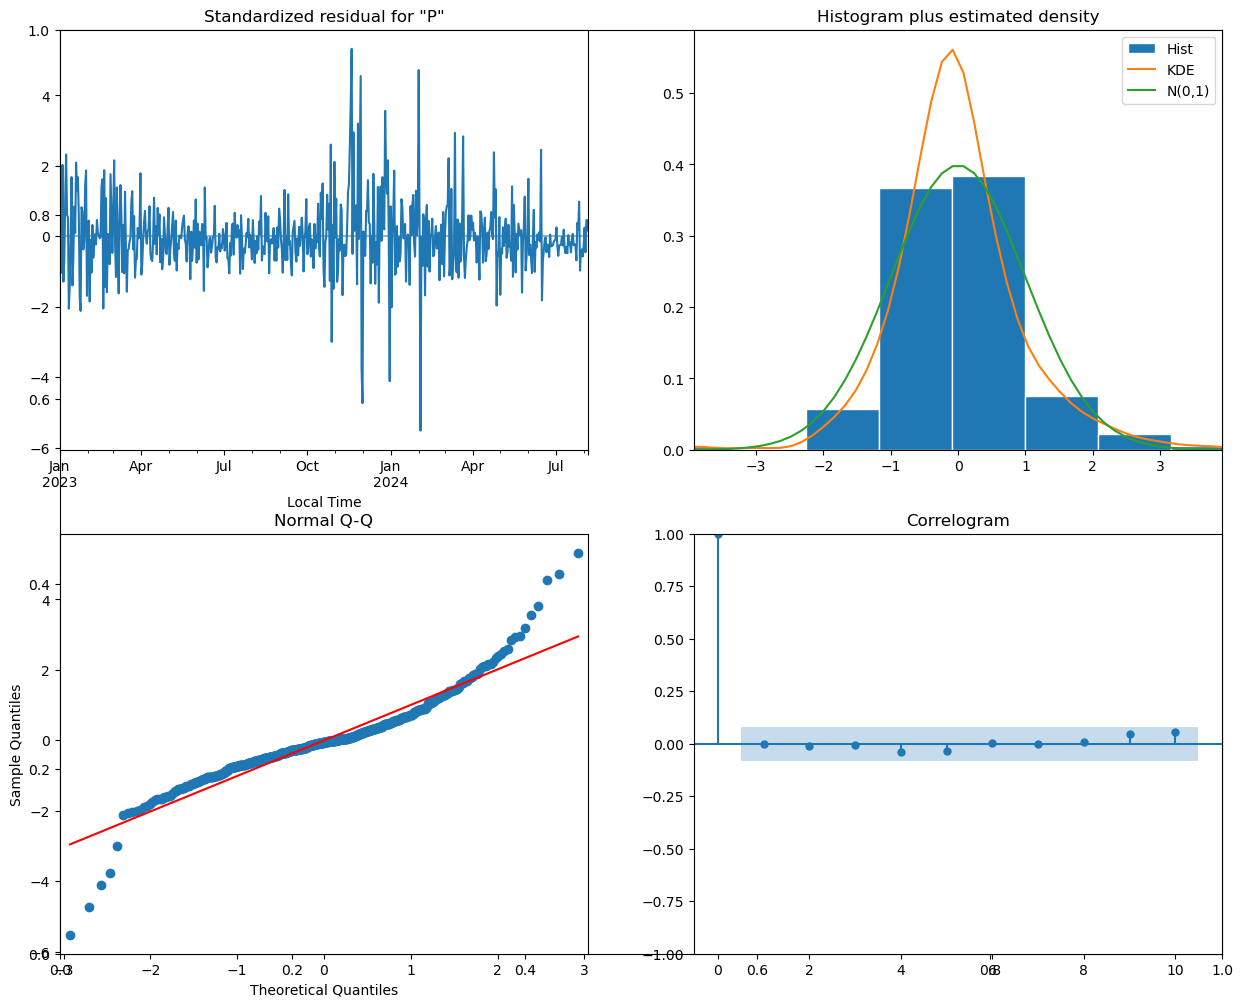

In [35]:
model = ARIMA(df_pm25_train, order=(5,0,2))
results = model.fit()
fig, ax = plt.subplots(figsize=(15, 12))
results.plot_diagnostics(fig=fig)
# Save the plot as an image file (e.g., PNG)
plt.savefig('example_plot.png')

In [28]:
df_pm25_pred_wfv = pd.Series()  # Initialize as an empty Series instead of a list
history = df_pm25_train.copy()
for i in range(len(df_pm25_test)):
    model = ARIMA(history, order = (5, 1, 1)).fit()
    next_pred = model.forecast()
    df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])
    # Round the entire Series to 2 decimals
    df_pm25_pred_wfv = df_pm25_pred_wfv.round(2)
    history = pd.concat([history, df_pm25_test[next_pred.index]])


C:\Users\media\AppData\Local\Temp\ipykernel_18360\222352973.py:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])


In [20]:
df_pm25_pred_wfv

2024-08-07    40.11
2024-08-08    60.76
2024-08-09    14.86
2024-08-10    24.81
2024-08-11    20.42
              ...  
2024-12-27    83.46
2024-12-28    62.74
2024-12-29    52.96
2024-12-30    79.90
2024-12-31    93.38
Freq: D, Length: 147, dtype: float64

In [21]:
test_mae = mean_absolute_error(df_pm25_test, df_pm25_pred_wfv)
print("Test MAE (walk forward validation):", round(test_mae, 2))

Test MAE (walk forward validation): 15.42


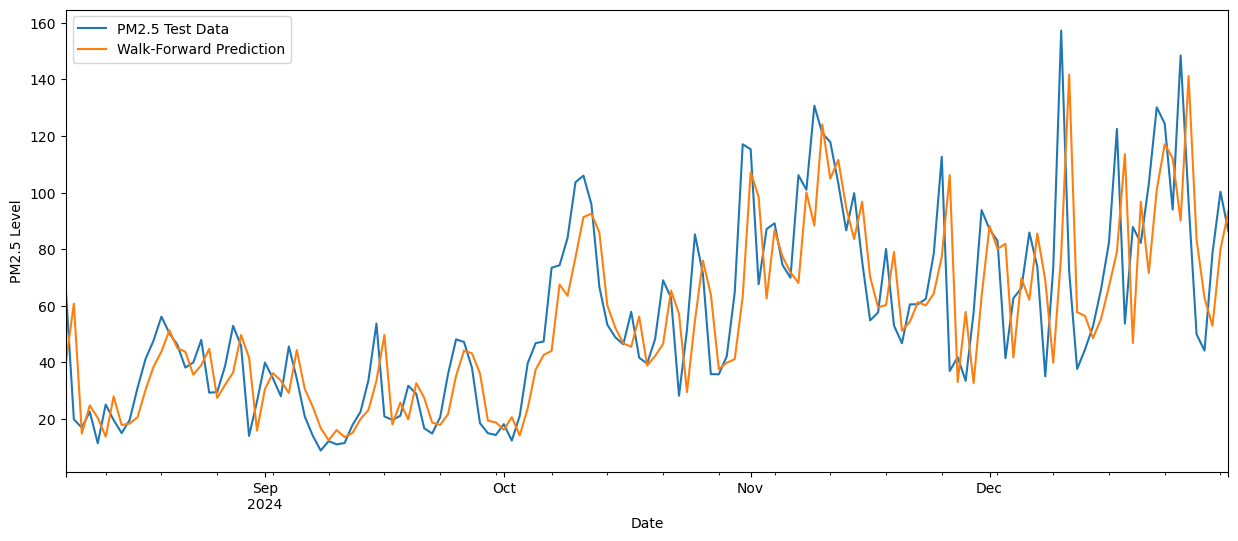

In [22]:
ax = df_pm25_test.plot(label = 'PM2.5 Test Data', figsize=(15, 6))
df_pm25_pred_wfv.plot(ax=ax, label='Walk-Forward Prediction')
plt.ylabel('PM2.5 Level')
plt.xlabel('Date')
plt.legend()
plt.show()

Biểu đồ trên cho thấy sự so sánh giữa dữ liệu thử nghiệm PM2.5 và Dự đoán Tiến tới (Walt-Forward Prediction). Đường màu xanh biểu thị mức PM2.5 thực tế được quan sát trong tập dữ liệu thử nghiệm, trong khi đường màu cam biểu thị các dự đoán được thực hiện bởi mô hình ARIMA bằng cách sử dụng xác thực tiến tới (Walt-Forward Validation).

Từ biểu đồ, có thể thấy rõ rằng các dự đoán của mô hình bám sát xu hướng dữ liệu thử nghiệm thực tế, nắm bắt được các đỉnh và đáy đáng kể. Điều này cho thấy mô hình hoạt động tốt trong việc dự báo mức PM2.5, mang lại dự đoán mạnh mẽ và đáng tin cậy. Sự gần gũi của hai đường cho thấy mô hình hiệu quả trong việc nắm bắt các mô hình cơ bản và tính thời vụ hiện diện trong dữ liệu chuỗi thời gian